# PROJET ETL - ANALYSE DES VENTES ET COMPORTEMENT CLIENT DANS UN SUPERMARCHÉ


Objectifs :
- Mettre en place un processus ETL complet
- Construire un entrepôt de données en étoile
- Analyser ventes, clients, et produits
- Créer des visualisations avec Matplotlib

Technologies : Python, Pandas, SQLAlchemy, PostgreSQL, Matplotlib


## INSTALLATION ET IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sqlalchemy import create_engine, text, Column, Integer, String, Float, Date, Boolean, ForeignKey
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import warnings
import random
from faker import Faker

In [2]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports réussis")

✓ Imports réussis


## CONFIGURATION DE LA BASE DE DONNÉES

In [4]:
# Configuration PostgreSQL - À MODIFIER selon votre environnement
DB_CONFIG = {
    'user': USER_ID,
    'password': USER_PWD,
    'host': 'localhost',
    'port': '5432',
    'database': 'supermarket_dw'
}

In [5]:
# Création de la chaîne de connexion
DATABASE_URL = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

In [6]:
# Création de l'engine SQLAlchemy
try:
    engine = create_engine(DATABASE_URL, echo=False)
    Base = declarative_base()
    print("✓ Connexion à PostgreSQL réussie")
except Exception as e:
    print(f"✗ Erreur de connexion : {e}")
    print("Note : Modifiez DB_CONFIG avec vos identifiants PostgreSQL")

✓ Connexion à PostgreSQL réussie


## GÉNÉRATION DE DONNÉES FICTIVES RÉALISTES

In [7]:
fake = Faker('fr_FR')
np.random.seed(42)
random.seed(42)

#### Génération des PRODUITS

In [8]:
print("\n[1/5] Génération des produits...")

categories = {
    'Fruits & Légumes': ['Pommes', 'Bananes', 'Tomates', 'Carottes', 'Salade', 'Oranges', 'Fraises', 'Courgettes'],
    'Viandes & Poissons': ['Poulet', 'Boeuf haché', 'Saumon', 'Jambon', 'Steak', 'Crevettes', 'Thon'],
    'Produits laitiers': ['Lait', 'Yaourts', 'Fromage', 'Beurre', 'Crème fraîche', 'Mozzarella'],
    'Épicerie': ['Pâtes', 'Riz', 'Huile', 'Farine', 'Sucre', 'Sel', 'Café', 'Thé', 'Conserves'],
    'Boissons': ['Eau minérale', 'Jus orange', 'Coca-Cola', 'Vin rouge', 'Bière', 'Jus pomme'],
    'Hygiène & Beauté': ['Shampoing', 'Savon', 'Dentifrice', 'Déodorant', 'Crème visage'],
    'Entretien': ['Lessive', 'Liquide vaisselle', 'Éponges', 'Javel', 'Nettoyant sol']
}

fournisseurs = ['Lactalis', 'Danone', 'Nestlé', 'Carrefour Production', 'Système U', 'Intermarché', 'Bio Coop']

produits_data = []
produit_id = 1

for categorie, items in categories.items():
    for item in items:
        produits_data.append({
            'produit_id': produit_id,
            'code_produit': f'PRD{produit_id:05d}',
            'nom_produit': item,
            'categorie': categorie,
            'fournisseur': random.choice(fournisseurs),
            'prix_unitaire': round(random.uniform(1.5, 25.0), 2),
            'stock_disponible': random.randint(50, 500)
        })
        produit_id += 1

df_produits = pd.DataFrame(produits_data)
print(f"✓ {len(df_produits)} produits générés")


[1/5] Génération des produits...
✓ 46 produits générés


#### Génération de la dimension TEMPS

In [9]:
print("\n[2/5] Génération de la dimension temps...")

start_date = datetime(2023, 1, 1)
end_date = datetime(2025, 12, 31)
dates = pd.date_range(start_date, end_date, freq='D')

jours_feries_fr = [
    '2023-01-01', '2023-04-10', '2023-05-01', '2023-05-08', '2023-07-14', '2023-08-15', '2023-11-01', '2023-12-25',
    '2024-01-01', '2024-04-01', '2024-05-01', '2024-05-08', '2024-07-14', '2024-08-15', '2024-11-01', '2024-12-25',
    '2025-01-01', '2025-04-21', '2025-05-01', '2025-05-08', '2025-07-14', '2025-08-15', '2025-11-01', '2025-12-25'
]

temps_data = []
for idx, date in enumerate(dates, 1):
    temps_data.append({
        'date_id': idx,
        'date_complete': date,
        'jour': date.day,
        'mois': date.month,
        'trimestre': (date.month - 1) // 3 + 1,
        'annee': date.year,
        'jour_semaine': date.weekday() + 1,
        'nom_jour': date.strftime('%A'),
        'semaine_annee': date.isocalendar()[1],
        'est_weekend': date.weekday() >= 5,
        'est_ferie': date.strftime('%Y-%m-%d') in jours_feries_fr
    })

df_temps = pd.DataFrame(temps_data)
print(f"✓ {len(df_temps)} dates générées (2023-2025)")


[2/5] Génération de la dimension temps...
✓ 1096 dates générées (2023-2025)


#### Génération des CLIENTS

In [10]:
print("\n[3/5] Génération des clients...")

statuts_fidelite = ['Bronze', 'Silver', 'Gold', 'Platinum']
villes_fr = [
    ('Paris', 'Île-de-France', '75000'),
    ('Lyon', 'Auvergne-Rhône-Alpes', '69000'),
    ('Marseille', 'Provence-Alpes-Côte d\'Azur', '13000'),
    ('Toulouse', 'Occitanie', '31000'),
    ('Bordeaux', 'Nouvelle-Aquitaine', '33000'),
    ('Lille', 'Hauts-de-France', '59000'),
    ('Nantes', 'Pays de la Loire', '44000'),
    ('Strasbourg', 'Grand Est', '67000')
]

clients_data = []
for i in range(1, 5001):
    ville, region, cp_base = random.choice(villes_fr)
    age = random.randint(18, 80)
    
    if age < 26:
        tranche_age = '18-25'
    elif age < 36:
        tranche_age = '26-35'
    elif age < 51:
        tranche_age = '36-50'
    elif age < 66:
        tranche_age = '51-65'
    else:
        tranche_age = '66+'
    
    clients_data.append({
        'client_id': i,
        'age': age,
        'tranche_age': tranche_age,
        'sexe': random.choice(['M', 'F']),
        'code_postal': cp_base,
        'ville': ville,
        'region': region,
        'statut_fidelite': random.choice(statuts_fidelite),
        'date_inscription': fake.date_between(start_date='-3y', end_date='today'),
        'segment_client': random.choice(['Occasionnel', 'Régulier', 'VIP'])
    })

df_clients = pd.DataFrame(clients_data)
print(f"✓ {len(df_clients)} clients générés")


[3/5] Génération des clients...
✓ 5000 clients générés


#### Génération des MAGASINS

In [11]:
print("\n[4/5] Génération des magasins...")

magasins_data = [
    {'magasin_id': 1, 'nom_magasin': 'Supermarché Paris Centre', 'ville': 'Paris', 'region': 'Île-de-France', 'code_postal': '75001', 'surface_m2': 1200, 'type_magasin': 'Hypermarché'},
    {'magasin_id': 2, 'nom_magasin': 'Supermarché Lyon Part-Dieu', 'ville': 'Lyon', 'region': 'Auvergne-Rhône-Alpes', 'code_postal': '69003', 'surface_m2': 800, 'type_magasin': 'Supermarché'},
    {'magasin_id': 3, 'nom_magasin': 'Supermarché Marseille Vieux-Port', 'ville': 'Marseille', 'region': 'Provence-Alpes-Côte d\'Azur', 'code_postal': '13001', 'surface_m2': 950, 'type_magasin': 'Supermarché'},
    {'magasin_id': 4, 'nom_magasin': 'Supermarché Toulouse Capitole', 'ville': 'Toulouse', 'region': 'Occitanie', 'code_postal': '31000', 'surface_m2': 700, 'type_magasin': 'Proximité'},
    {'magasin_id': 5, 'nom_magasin': 'Supermarché Bordeaux Centre', 'ville': 'Bordeaux', 'region': 'Nouvelle-Aquitaine', 'code_postal': '33000', 'surface_m2': 1000, 'type_magasin': 'Supermarché'}
]

df_magasins = pd.DataFrame(magasins_data)
print(f"✓ {len(df_magasins)} magasins générés")


[4/5] Génération des magasins...
✓ 5 magasins générés


#### Génération des VENTES (Table de faits)

In [12]:
print("\n[5/5] Génération des transactions de vente...")

ventes_data = []
vente_id = 1


[5/5] Génération des transactions de vente...


### Générer 50000 transactions

In [13]:
num_transactions = 50000

for _ in range(num_transactions):
    date_vente = random.choice(df_temps['date_complete'].tolist())
    date_id = df_temps[df_temps['date_complete'] == date_vente]['date_id'].values[0]
    
    produit = df_produits.sample(1).iloc[0]
    client = df_clients.sample(1).iloc[0]
    magasin = df_magasins.sample(1).iloc[0]
    
    quantite = random.randint(1, 10)
    montant_unitaire = produit['prix_unitaire']
    montant_total = quantite * montant_unitaire
    
    # Remise selon fidélité
    remise_pct = {'Bronze': 0, 'Silver': 0.05, 'Gold': 0.10, 'Platinum': 0.15}
    remise = montant_total * remise_pct.get(client['statut_fidelite'], 0)
    montant_net = montant_total - remise
    
    ventes_data.append({
        'vente_id': vente_id,
        'date_id': int(date_id),
        'produit_id': int(produit['produit_id']),
        'client_id': int(client['client_id']),
        'magasin_id': int(magasin['magasin_id']),
        'quantite': quantite,
        'montant_unitaire': montant_unitaire,
        'montant_total': round(montant_total, 2),
        'remise': round(remise, 2),
        'montant_net': round(montant_net, 2)
    })
    vente_id += 1

df_ventes = pd.DataFrame(ventes_data)
print(f"✓ {len(df_ventes)} transactions générées")

print("\n" + "="*80)
print("RÉSUMÉ DES DONNÉES GÉNÉRÉES")
print("="*80)
print(f"Produits     : {len(df_produits):,}")
print(f"Clients      : {len(df_clients):,}")
print(f"Magasins     : {len(df_magasins):,}")
print(f"Dates        : {len(df_temps):,}")
print(f"Transactions : {len(df_ventes):,}")
print(f"CA Total     : {df_ventes['montant_net'].sum():,.2f} €")

✓ 50000 transactions générées

RÉSUMÉ DES DONNÉES GÉNÉRÉES
Produits     : 46
Clients      : 5,000
Magasins     : 5
Dates        : 1,096
Transactions : 50,000
CA Total     : 2,576,421.14 €


## EXPLORATION ET NETTOYAGE DES DONNÉES (ETL - EXTRACT & TRANSFORM)

#### Vérification de la qualité

In [15]:
print("\n[Qualité des données]")

for name, df in [('Produits', df_produits), ('Clients', df_clients), 
                 ('Magasins', df_magasins), ('Temps', df_temps), ('Ventes', df_ventes)]:
    missing = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()
    print(f"{name:12} - Manquants: {missing:4}, Doublons: {duplicates:4}")


[Qualité des données]
Produits     - Manquants:    0, Doublons:    0
Clients      - Manquants:    0, Doublons:    0
Magasins     - Manquants:    0, Doublons:    0
Temps        - Manquants:    0, Doublons:    0
Ventes       - Manquants:    0, Doublons:    0


#### Statistiques descriptives

In [16]:
print("\n[Statistiques des ventes]")
print(df_ventes[['quantite', 'montant_unitaire', 'montant_total', 'montant_net']].describe())



[Statistiques des ventes]
           quantite  montant_unitaire  montant_total   montant_net
count  50000.000000      50000.000000   50000.000000  50000.000000
mean       5.486260         10.167937      55.774921     51.528423
std        2.862638          5.558359      45.063272     41.831704
min        1.000000          1.650000       1.650000      1.400000
25%        3.000000          6.170000      20.600000     18.630000
50%        5.000000          9.940000      43.190000     39.400000
75%        8.000000         14.590000      80.010000     72.980000
max       10.000000         23.510000     235.100000    235.100000


#### Ajout de colonnes calculées

In [17]:
df_ventes['panier_moyen'] = df_ventes['montant_net'] / df_ventes['quantite']

print("\n✓ Données nettoyées et enrichies")


✓ Données nettoyées et enrichies


## CRÉATION DU SCHÉMA EN ÉTOILE DANS POSTGRESQL (ETL - LOAD)

#### Définition des tables avec SQLAlchemy ORM

In [18]:
from sqlalchemy import MetaData
metadata = MetaData()

In [19]:
# Suppression des tables existantes et recréation
print("\n[Création des tables...]")

with engine.connect() as conn:
    # Suppression en ordre inverse des dépendances
    conn.execute(text("DROP TABLE IF EXISTS fait_ventes CASCADE"))
    conn.execute(text("DROP TABLE IF EXISTS dim_produit CASCADE"))
    conn.execute(text("DROP TABLE IF EXISTS dim_client CASCADE"))
    conn.execute(text("DROP TABLE IF EXISTS dim_magasin CASCADE"))
    conn.execute(text("DROP TABLE IF EXISTS dim_temps CASCADE"))
    conn.commit()



[Création des tables...]


#### Création des tables

In [20]:
sql_create_tables = """
-- Dimension Temps
CREATE TABLE dim_temps (
    date_id INTEGER PRIMARY KEY,
    date_complete DATE NOT NULL,
    jour INTEGER,
    mois INTEGER,
    trimestre INTEGER,
    annee INTEGER,
    jour_semaine INTEGER,
    nom_jour VARCHAR(20),
    semaine_annee INTEGER,
    est_weekend BOOLEAN,
    est_ferie BOOLEAN
);

-- Dimension Produit
CREATE TABLE dim_produit (
    produit_id INTEGER PRIMARY KEY,
    code_produit VARCHAR(20),
    nom_produit VARCHAR(100),
    categorie VARCHAR(50),
    fournisseur VARCHAR(100),
    prix_unitaire NUMERIC(10,2),
    stock_disponible INTEGER
);

-- Dimension Client
CREATE TABLE dim_client (
    client_id INTEGER PRIMARY KEY,
    age INTEGER,
    tranche_age VARCHAR(10),
    sexe CHAR(1),
    code_postal VARCHAR(10),
    ville VARCHAR(100),
    region VARCHAR(100),
    statut_fidelite VARCHAR(20),
    date_inscription DATE,
    segment_client VARCHAR(20)
);

-- Dimension Magasin
CREATE TABLE dim_magasin (
    magasin_id INTEGER PRIMARY KEY,
    nom_magasin VARCHAR(100),
    ville VARCHAR(100),
    region VARCHAR(100),
    code_postal VARCHAR(10),
    surface_m2 INTEGER,
    type_magasin VARCHAR(50)
);

-- Table de Faits Ventes
CREATE TABLE fait_ventes (
    vente_id INTEGER PRIMARY KEY,
    date_id INTEGER REFERENCES dim_temps(date_id),
    produit_id INTEGER REFERENCES dim_produit(produit_id),
    client_id INTEGER REFERENCES dim_client(client_id),
    magasin_id INTEGER REFERENCES dim_magasin(magasin_id),
    quantite INTEGER,
    montant_unitaire NUMERIC(10,2),
    montant_total NUMERIC(10,2),
    remise NUMERIC(10,2),
    montant_net NUMERIC(10,2)
);

-- Index pour optimiser les requêtes
CREATE INDEX idx_ventes_date ON fait_ventes(date_id);
CREATE INDEX idx_ventes_produit ON fait_ventes(produit_id);
CREATE INDEX idx_ventes_client ON fait_ventes(client_id);
CREATE INDEX idx_ventes_magasin ON fait_ventes(magasin_id);
"""

with engine.connect() as conn:
    for statement in sql_create_tables.split(';'):
        if statement.strip():
            conn.execute(text(statement))
    conn.commit()

print("✓ Tables créées avec succès")

✓ Tables créées avec succès


#### Chargement des données dans PostgreSQL

In [21]:
print("\n[Chargement des données...]")

try:
    # Chargement des dimensions d'abord
    df_temps.to_sql('dim_temps', engine, if_exists='append', index=False)
    print("✓ dim_temps chargée")
    
    df_produits.to_sql('dim_produit', engine, if_exists='append', index=False)
    print("✓ dim_produit chargée")
    
    df_clients.to_sql('dim_client', engine, if_exists='append', index=False)
    print("✓ dim_client chargée")
    
    df_magasins.to_sql('dim_magasin', engine, if_exists='append', index=False)
    print("✓ dim_magasin chargée")
    
    # Chargement de la table de faits
    df_ventes_load = df_ventes[['vente_id', 'date_id', 'produit_id', 'client_id', 
                                 'magasin_id', 'quantite', 'montant_unitaire', 
                                 'montant_total', 'remise', 'montant_net']]
    df_ventes_load.to_sql('fait_ventes', engine, if_exists='append', index=False)
    print("✓ fait_ventes chargée")
    
    print("\n✓ Data Warehouse chargé avec succès !")
    
except Exception as e:
    print(f"✗ Erreur lors du chargement : {e}")


[Chargement des données...]
✓ dim_temps chargée
✓ dim_produit chargée
✓ dim_client chargée
✓ dim_magasin chargée
✓ fait_ventes chargée

✓ Data Warehouse chargé avec succès !


## REQUÊTES OLAP ET ANALYSES MULTIDIMENSIONNELLES

#### Top 10 Produits par CA

In [22]:
print("\n[Analyse 1] Top 10 Produits par Chiffre d'Affaires")
query1 = """
SELECT 
    p.nom_produit,
    p.categorie,
    COUNT(v.vente_id) as nb_ventes,
    SUM(v.quantite) as quantite_totale,
    SUM(v.montant_net) as ca_total
FROM fait_ventes v
JOIN dim_produit p ON v.produit_id = p.produit_id
GROUP BY p.nom_produit, p.categorie
ORDER BY ca_total DESC
LIMIT 10
"""
top_produits = pd.read_sql(query1, engine)
print(top_produits.to_string(index=False))


[Analyse 1] Top 10 Produits par Chiffre d'Affaires
      nom_produit          categorie  nb_ventes  quantite_totale  ca_total
            Sucre           Épicerie       1049             5897 128575.25
     Eau minérale           Boissons       1104             5920 116333.43
            Savon   Hygiène & Beauté       1168             6465 113644.71
       Dentifrice   Hygiène & Beauté       1114             6009 105787.69
           Saumon Viandes & Poissons       1114             6234 103052.82
             Café           Épicerie       1044             5467  94422.59
              Sel           Épicerie       1103             6177  89899.54
Liquide vaisselle          Entretien       1112             5960  89284.36
           Poulet Viandes & Poissons       1089             6119  86762.71
          Fromage  Produits laitiers       1024             5591  83972.41


#### CA par Mois et Année

In [23]:
print("\n[Analyse 2] Évolution du CA Mensuel")
query2 = """
SELECT 
    t.annee,
    t.mois,
    COUNT(DISTINCT v.vente_id) as nb_transactions,
    SUM(v.montant_net) as ca_mensuel,
    AVG(v.montant_net) as panier_moyen
FROM fait_ventes v
JOIN dim_temps t ON v.date_id = t.date_id
GROUP BY t.annee, t.mois
ORDER BY t.annee, t.mois
"""
ca_mensuel = pd.read_sql(query2, engine)
print(ca_mensuel.head(12).to_string(index=False))


[Analyse 2] Évolution du CA Mensuel
 annee  mois  nb_transactions  ca_mensuel  panier_moyen
  2023     1             1448    74124.94     51.191257
  2023     2             1260    64072.92     50.851524
  2023     3             1416    75008.47     52.972083
  2023     4             1374    72314.64     52.630742
  2023     5             1445    74284.52     51.407972
  2023     6             1443    74104.65     51.354574
  2023     7             1439    71765.16     49.871550
  2023     8             1425    73906.86     51.864463
  2023     9             1294    65958.43     50.972512
  2023    10             1383    72298.52     52.276587
  2023    11             1393    68134.03     48.911723
  2023    12             1377    73329.07     53.252774


#### Segmentation Clients

In [24]:
print("\n[Analyse 3] Performance par Segment de Clients")
query3 = """
SELECT 
    c.segment_client,
    c.statut_fidelite,
    COUNT(DISTINCT v.client_id) as nb_clients,
    SUM(v.montant_net) as ca_total,
    AVG(v.montant_net) as panier_moyen,
    COUNT(v.vente_id) as nb_achats
FROM fait_ventes v
JOIN dim_client c ON v.client_id = c.client_id
GROUP BY c.segment_client, c.statut_fidelite
ORDER BY ca_total DESC
"""
segmentation = pd.read_sql(query3, engine)
print(segmentation.to_string(index=False))


[Analyse 3] Performance par Segment de Clients
segment_client statut_fidelite  nb_clients  ca_total  panier_moyen  nb_achats
      Régulier          Bronze         438 240943.80     56.242717       4284
           VIP          Silver         422 228606.71     53.201468       4297
   Occasionnel          Bronze         401 222937.97     54.978538       4055
   Occasionnel          Silver         432 220983.42     52.565038       4204
      Régulier          Silver         415 219001.09     53.001232       4132
           VIP          Bronze         392 211859.14     55.056949       3848
   Occasionnel            Gold         415 210775.60     50.124994       4205
   Occasionnel        Platinum         435 209283.46     47.661913       4391
           VIP        Platinum         427 206172.58     48.295287       4269
      Régulier            Gold         398 203437.53     50.669372       4015
           VIP            Gold         403 202109.81     50.027181       4040
      Régulier  

#### Performance Géographique

In [25]:
print("\n[Analyse 4] CA par Région")
query4 = """
SELECT 
    m.region,
    COUNT(DISTINCT m.magasin_id) as nb_magasins,
    SUM(v.montant_net) as ca_total,
    SUM(v.montant_net) / COUNT(DISTINCT m.magasin_id) as ca_par_magasin
FROM fait_ventes v
JOIN dim_magasin m ON v.magasin_id = m.magasin_id
GROUP BY m.region
ORDER BY ca_total DESC
"""
ca_region = pd.read_sql(query4, engine)
print(ca_region.to_string(index=False))


[Analyse 4] CA par Région
                    region  nb_magasins  ca_total  ca_par_magasin
        Nouvelle-Aquitaine            1 521717.17       521717.17
                 Occitanie            1 520657.36       520657.36
      Auvergne-Rhône-Alpes            1 518993.02       518993.02
Provence-Alpes-Côte d'Azur            1 513672.00       513672.00
             Île-de-France            1 501381.59       501381.59


#### Analyse Catégories × Trimestre

In [26]:
print("\n[Analyse 5] CA par Catégorie et Trimestre (Saisonnalité)")
query5 = """
SELECT 
    p.categorie,
    t.trimestre,
    t.annee,
    SUM(v.montant_net) as ca
FROM fait_ventes v
JOIN dim_produit p ON v.produit_id = p.produit_id
JOIN dim_temps t ON v.date_id = t.date_id
WHERE t.annee = 2024
GROUP BY p.categorie, t.trimestre, t.annee
ORDER BY p.categorie, t.trimestre
"""
saisonnalite = pd.read_sql(query5, engine)
print(saisonnalite.head(20).to_string(index=False))


[Analyse 5] CA par Catégorie et Trimestre (Saisonnalité)
       categorie  trimestre  annee       ca
        Boissons          1   2024 30800.13
        Boissons          2   2024 27286.95
        Boissons          3   2024 29752.74
        Boissons          4   2024 25718.33
       Entretien          1   2024 21438.75
       Entretien          2   2024 21058.15
       Entretien          3   2024 20262.13
       Entretien          4   2024 20576.26
        Épicerie          1   2024 54255.27
        Épicerie          2   2024 50628.70
        Épicerie          3   2024 51191.24
        Épicerie          4   2024 50733.63
Fruits & Légumes          1   2024 22177.01
Fruits & Légumes          2   2024 26411.79
Fruits & Légumes          3   2024 24320.06
Fruits & Légumes          4   2024 25748.57
Hygiène & Beauté          1   2024 34435.55
Hygiène & Beauté          2   2024 27498.66
Hygiène & Beauté          3   2024 31077.55
Hygiène & Beauté          4   2024 31716.72


#### Analyse RFM (Récence, Fréquence, Montant)

In [27]:
print("\n[Analyse 6] Segmentation RFM des Clients")
query6 = """
WITH rfm AS (
    SELECT 
        c.client_id,
        c.segment_client,
        MAX(t.date_complete) as derniere_visite,
        COUNT(v.vente_id) as frequence,
        SUM(v.montant_net) as montant_total
    FROM fait_ventes v
    JOIN dim_client c ON v.client_id = c.client_id
    JOIN dim_temps t ON v.date_id = t.date_id
    GROUP BY c.client_id, c.segment_client
)
SELECT 
    segment_client,
    COUNT(*) as nb_clients,
    AVG(frequence) as freq_moyenne,
    AVG(montant_total) as montant_moyen,
    SUM(montant_total) as ca_total
FROM rfm
GROUP BY segment_client
ORDER BY ca_total DESC
"""
rfm_analysis = pd.read_sql(query6, engine)
print(rfm_analysis.to_string(index=False))


[Analyse 6] Segmentation RFM des Clients
segment_client  nb_clients  freq_moyenne  montant_moyen  ca_total
   Occasionnel        1683     10.014854     513.357368 863980.45
      Régulier        1673      9.976689     516.253706 863692.45
           VIP        1644     10.008516     516.270219 848748.24


## VISUALISATIONS AVEC MATPLOTLIB

In [28]:
# Configuration générale des graphiques
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

#### Dashboard Principal (4 graphiques)

✓ Dashboard principal sauvegardé : dashboard_principal.png


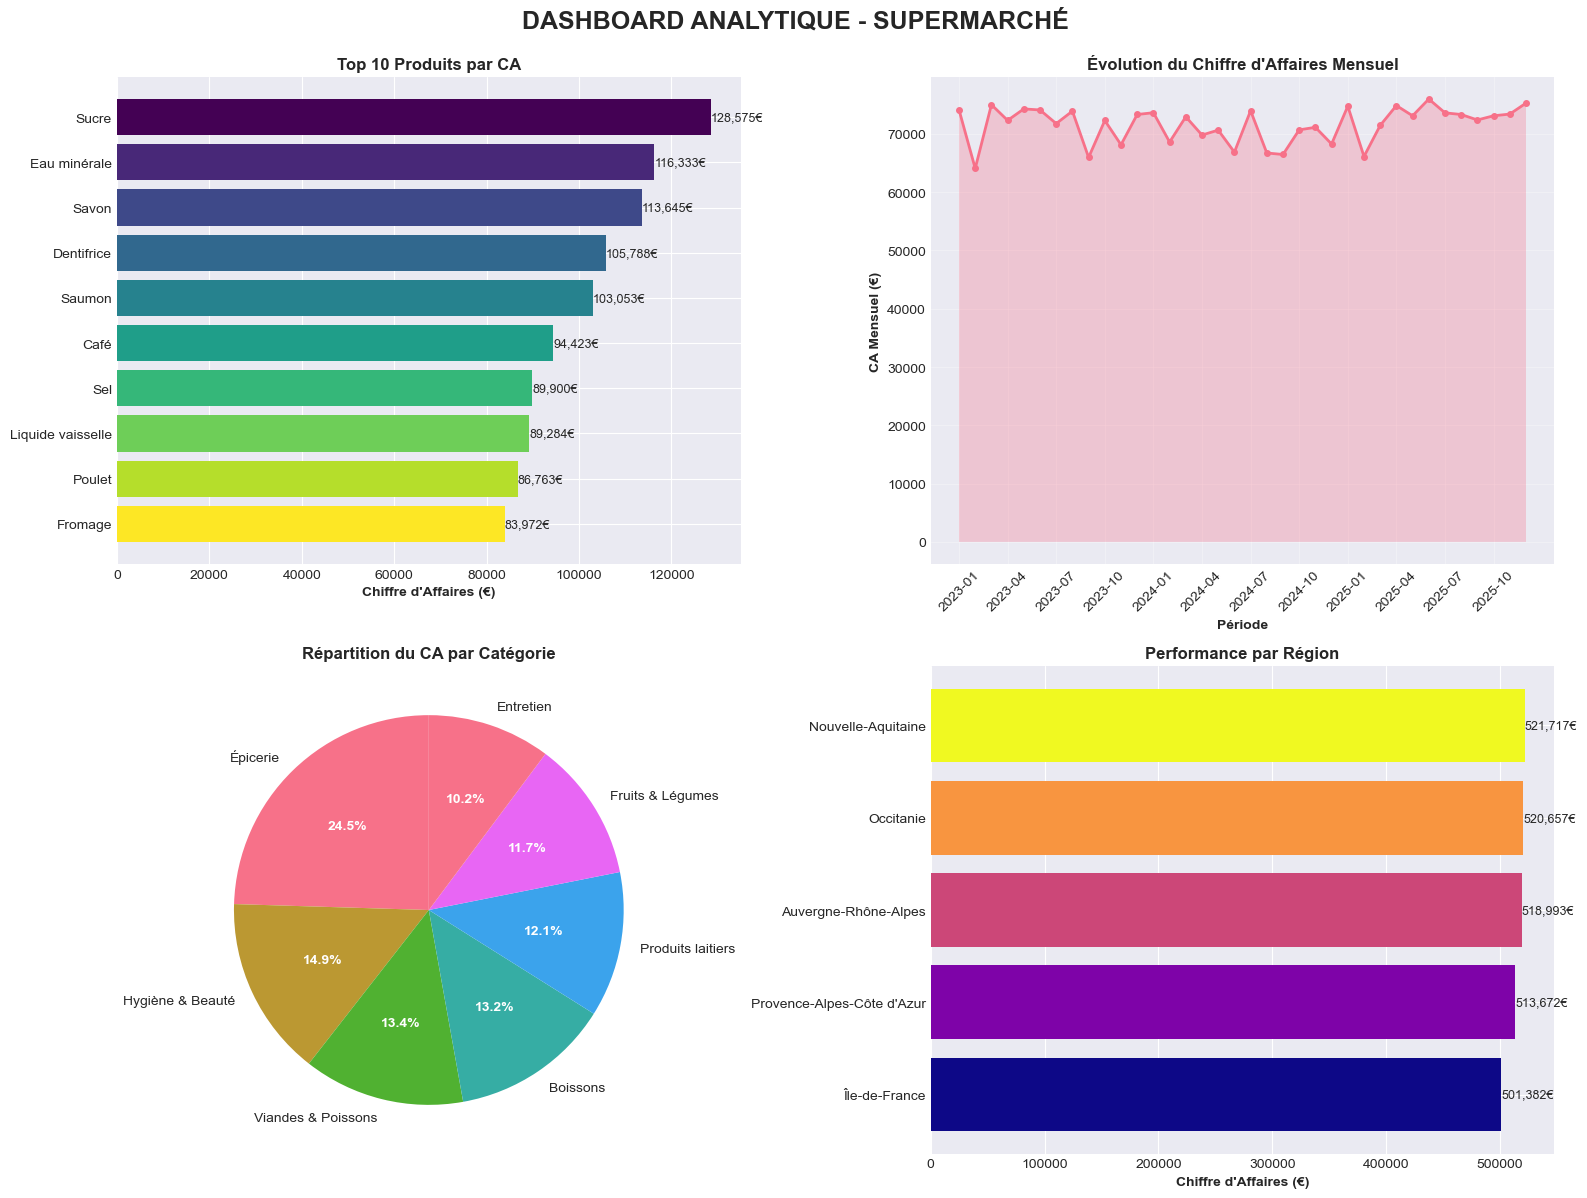

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DASHBOARD ANALYTIQUE - SUPERMARCHÉ', fontsize=18, fontweight='bold', y=0.995)
# Graph 1: Top 10 Produits
ax1 = axes[0, 0]
top_10 = top_produits.head(10)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_10)))
bars = ax1.barh(top_10['nom_produit'], top_10['ca_total'], color=colors)
ax1.set_xlabel('Chiffre d\'Affaires (€)', fontweight='bold')
ax1.set_title('Top 10 Produits par CA', fontweight='bold', fontsize=12)
ax1.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_10['ca_total'])):
    ax1.text(val, bar.get_y() + bar.get_height()/2, f'{val:,.0f}€', 
             va='center', ha='left', fontsize=9)

# Graph 2: Évolution CA Mensuel
ax2 = axes[0, 1]
ca_mensuel['periode'] = ca_mensuel['annee'].astype(str) + '-' + ca_mensuel['mois'].astype(str).str.zfill(2)
ax2.plot(range(len(ca_mensuel)), ca_mensuel['ca_mensuel'], marker='o', linewidth=2, markersize=4)
ax2.fill_between(range(len(ca_mensuel)), ca_mensuel['ca_mensuel'], alpha=0.3)
ax2.set_xlabel('Période', fontweight='bold')
ax2.set_ylabel('CA Mensuel (€)', fontweight='bold')
ax2.set_title('Évolution du Chiffre d\'Affaires Mensuel', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, len(ca_mensuel), 3))
ax2.set_xticklabels(ca_mensuel['periode'].iloc[::3], rotation=45)

# Graph 3: CA par Catégorie
ax3 = axes[1, 0]
query_cat = """
SELECT p.categorie, SUM(v.montant_net) as ca
FROM fait_ventes v
JOIN dim_produit p ON v.produit_id = p.produit_id
GROUP BY p.categorie
ORDER BY ca DESC
"""
ca_categorie = pd.read_sql(query_cat, engine)
wedges, texts, autotexts = ax3.pie(ca_categorie['ca'], labels=ca_categorie['categorie'], 
                                     autopct='%1.1f%%', startangle=90)
ax3.set_title('Répartition du CA par Catégorie', fontweight='bold', fontsize=12)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Graph 4: CA par Région
ax4 = axes[1, 1]
ca_region_sorted = ca_region.sort_values('ca_total', ascending=True)
colors_region = plt.cm.plasma(np.linspace(0, 1, len(ca_region_sorted)))
bars_region = ax4.barh(ca_region_sorted['region'], ca_region_sorted['ca_total'], color=colors_region)
ax4.set_xlabel('Chiffre d\'Affaires (€)', fontweight='bold')
ax4.set_title('Performance par Région', fontweight='bold', fontsize=12)
for bar, val in zip(bars_region, ca_region_sorted['ca_total']):
    ax4.text(val, bar.get_y() + bar.get_height()/2, f'{val:,.0f}€', 
             va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.savefig('dashboard_principal.png', dpi=300, bbox_inches='tight')
print("✓ Dashboard principal sauvegardé : dashboard_principal.png")
plt.show()

#### Analyse Temporelle Détaillée

✓ Analyse temporelle sauvegardée : analyse_temporelle.png


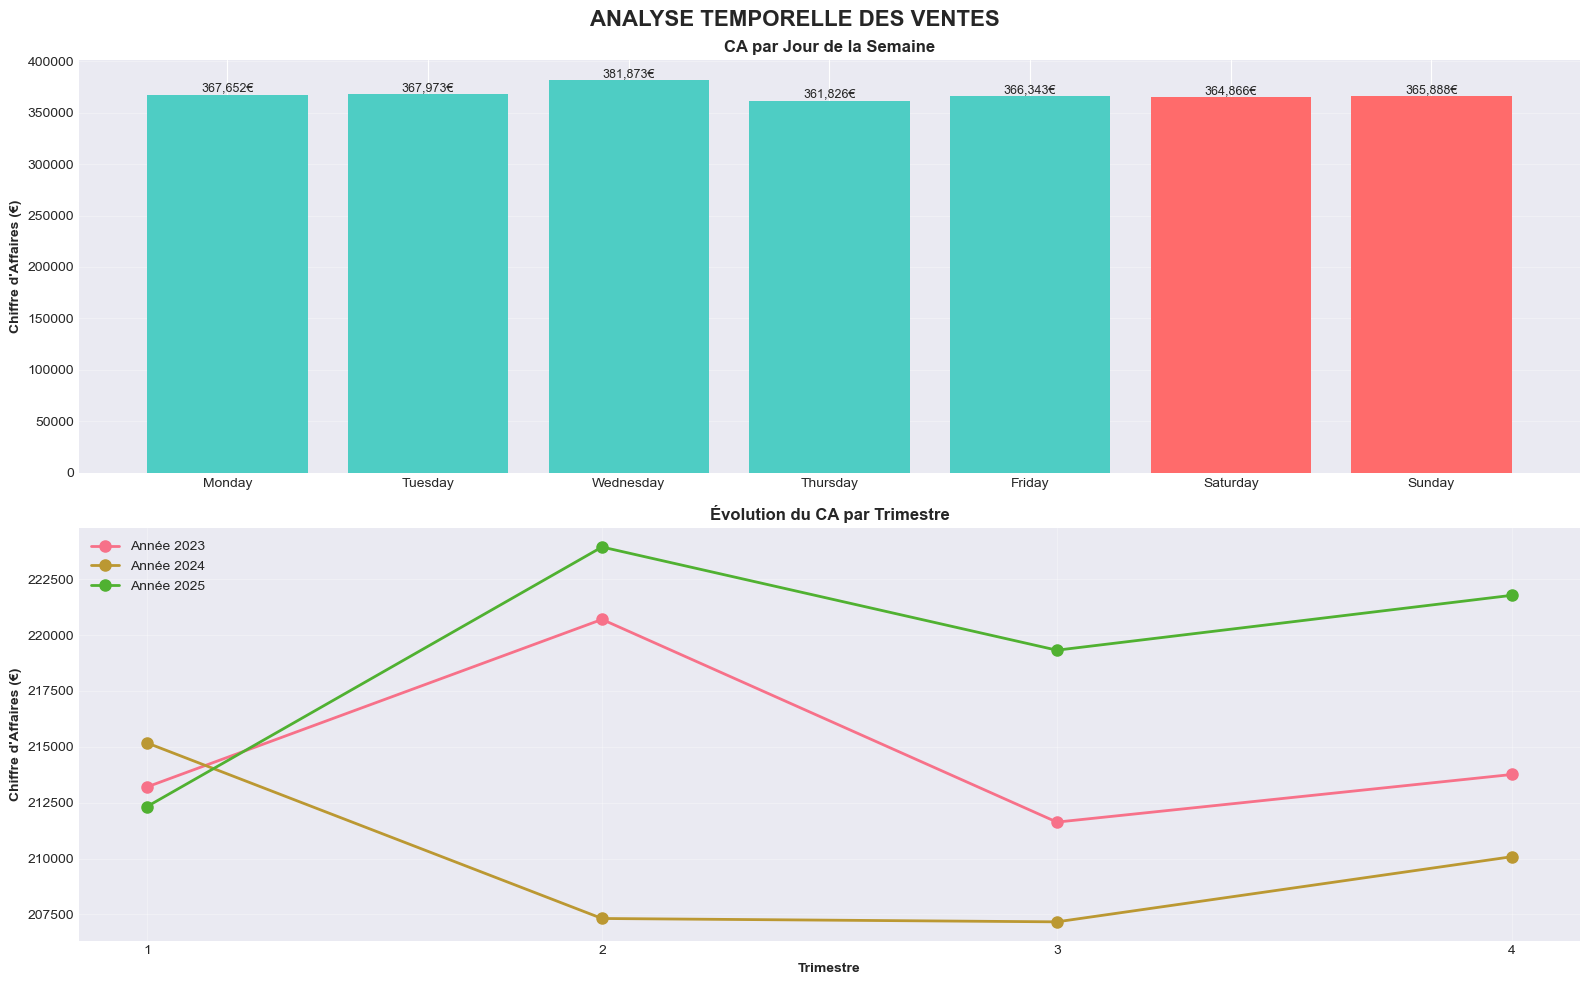

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('ANALYSE TEMPORELLE DES VENTES', fontsize=16, fontweight='bold')

# CA par jour de la semaine
ax1 = axes[0]
query_jour = """
SELECT 
    t.nom_jour,
    t.jour_semaine,
    SUM(v.montant_net) as ca_total,
    COUNT(v.vente_id) as nb_ventes
FROM fait_ventes v
JOIN dim_temps t ON v.date_id = t.date_id
GROUP BY t.nom_jour, t.jour_semaine
ORDER BY t.jour_semaine
"""
ca_jour = pd.read_sql(query_jour, engine)
colors_jour = ['#FF6B6B' if i >= 5 else '#4ECDC4' for i in range(len(ca_jour))]
bars = ax1.bar(ca_jour['nom_jour'], ca_jour['ca_total'], color=colors_jour)
ax1.set_ylabel('Chiffre d\'Affaires (€)', fontweight='bold')
ax1.set_title('CA par Jour de la Semaine', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, ca_jour['ca_total']):
    ax1.text(bar.get_x() + bar.get_width()/2, val, f'{val:,.0f}€', 
             ha='center', va='bottom', fontsize=9)
# CA par trimestre et année
ax2 = axes[1]
query_trim = """
SELECT 
    t.annee,
    t.trimestre,
    SUM(v.montant_net) as ca
FROM fait_ventes v
JOIN dim_temps t ON v.date_id = t.date_id
GROUP BY t.annee, t.trimestre
ORDER BY t.annee, t.trimestre
"""
ca_trim = pd.read_sql(query_trim, engine)
for annee in ca_trim['annee'].unique():
    data_annee = ca_trim[ca_trim['annee'] == annee]
    ax2.plot(data_annee['trimestre'], data_annee['ca'], marker='o', 
             linewidth=2, label=f'Année {int(annee)}', markersize=8)

ax2.set_xlabel('Trimestre', fontweight='bold')
ax2.set_ylabel('Chiffre d\'Affaires (€)', fontweight='bold')
ax2.set_title('Évolution du CA par Trimestre', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks([1, 2, 3, 4])

plt.tight_layout()
plt.savefig('analyse_temporelle.png', dpi=300, bbox_inches='tight')
print("✓ Analyse temporelle sauvegardée : analyse_temporelle.png")
plt.show()

#### Analyse Clients

✓ Analyse clients sauvegardée : analyse_clients.png


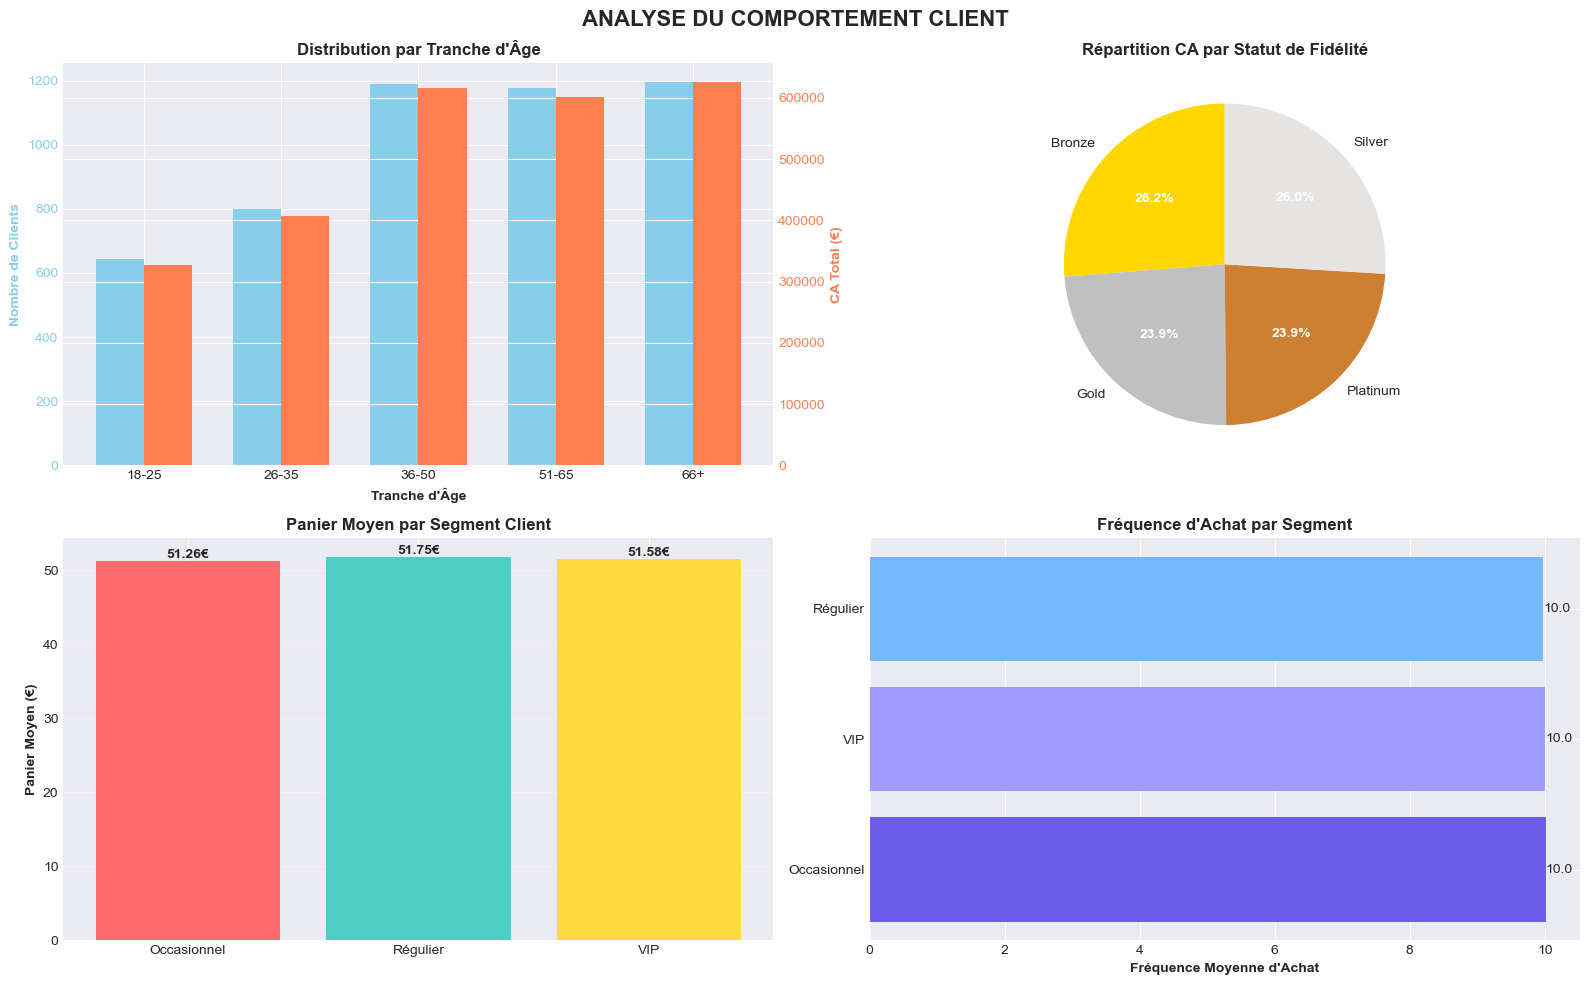

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ANALYSE DU COMPORTEMENT CLIENT', fontsize=16, fontweight='bold')

# Distribution par tranche d'âge
ax1 = axes[0, 0]
query_age = """
SELECT 
    c.tranche_age,
    COUNT(DISTINCT v.client_id) as nb_clients,
    SUM(v.montant_net) as ca_total
FROM fait_ventes v
JOIN dim_client c ON v.client_id = c.client_id
GROUP BY c.tranche_age
ORDER BY c.tranche_age
"""
ca_age = pd.read_sql(query_age, engine)
x = np.arange(len(ca_age))
width = 0.35
ax1_twin = ax1.twinx()
bars1 = ax1.bar(x - width/2, ca_age['nb_clients'], width, label='Nb Clients', color='skyblue')
bars2 = ax1_twin.bar(x + width/2, ca_age['ca_total'], width, label='CA Total', color='coral')
ax1.set_xlabel('Tranche d\'Âge', fontweight='bold')
ax1.set_ylabel('Nombre de Clients', fontweight='bold', color='skyblue')
ax1_twin.set_ylabel('CA Total (€)', fontweight='bold', color='coral')
ax1.set_title('Distribution par Tranche d\'Âge', fontweight='bold', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(ca_age['tranche_age'])
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1_twin.tick_params(axis='y', labelcolor='coral')

# Statut de fidélité
ax2 = axes[0, 1]
sizes = segmentation.groupby('statut_fidelite')['ca_total'].sum()
colors_fid = ['#FFD700', '#C0C0C0', '#CD7F32', '#E5E4E2']
wedges, texts, autotexts = ax2.pie(sizes, labels=sizes.index, autopct='%1.1f%%', 
                                     colors=colors_fid, startangle=90)
ax2.set_title('Répartition CA par Statut de Fidélité', fontweight='bold', fontsize=12)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Panier moyen par segment
ax3 = axes[1, 0]
panier_segment = segmentation.groupby('segment_client').agg({
    'ca_total': 'sum',
    'nb_achats': 'sum'
}).reset_index()
panier_segment['panier_moyen'] = panier_segment['ca_total'] / panier_segment['nb_achats']
bars = ax3.bar(panier_segment['segment_client'], panier_segment['panier_moyen'], 
               color=['#FF6B6B', '#4ECDC4', '#FFD93D'])
ax3.set_ylabel('Panier Moyen (€)', fontweight='bold')
ax3.set_title('Panier Moyen par Segment Client', fontweight='bold', fontsize=12)
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, panier_segment['panier_moyen']):
    ax3.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}€', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Fréquence d'achat
ax4 = axes[1, 1]
freq_data = rfm_analysis.sort_values('freq_moyenne', ascending=False)
bars = ax4.barh(freq_data['segment_client'], freq_data['freq_moyenne'], 
                color=['#6C5CE7', '#A29BFE', '#74B9FF'])
ax4.set_xlabel('Fréquence Moyenne d\'Achat', fontweight='bold')
ax4.set_title('Fréquence d\'Achat par Segment', fontweight='bold', fontsize=12)
for bar, val in zip(bars, freq_data['freq_moyenne']):
    ax4.text(val, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
             va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.savefig('analyse_clients.png', dpi=300, bbox_inches='tight')
print("✓ Analyse clients sauvegardée : analyse_clients.png")
plt.show()


#### Heatmap Saisonnalité

✓ Heatmap saisonnalité sauvegardée : heatmap_saisonnalite.png


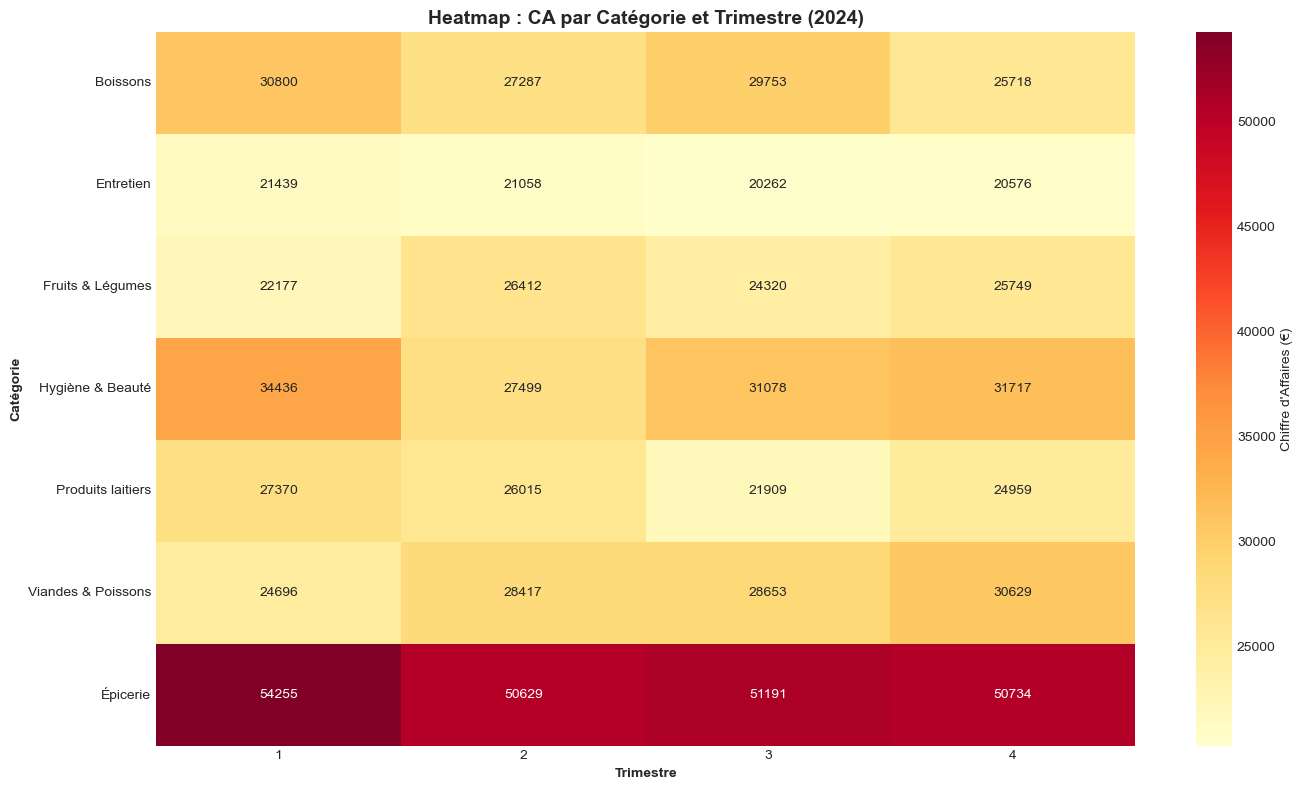

In [32]:
fig, ax = plt.subplots(figsize=(14, 8))
pivot_saison = saisonnalite.pivot(index='categorie', columns='trimestre', values='ca')
sns.heatmap(pivot_saison, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Chiffre d\'Affaires (€)'})
ax.set_title('Heatmap : CA par Catégorie et Trimestre (2024)', fontweight='bold', fontsize=14)
ax.set_xlabel('Trimestre', fontweight='bold')
ax.set_ylabel('Catégorie', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_saisonnalite.png', dpi=300, bbox_inches='tight')
print("✓ Heatmap saisonnalité sauvegardée : heatmap_saisonnalite.png")
plt.show()


## KPIs ET MÉTRIQUES CLÉS

Calcul des KPIs

In [33]:
query_kpis = """
SELECT 
    COUNT(DISTINCT v.vente_id) as nb_transactions,
    COUNT(DISTINCT v.client_id) as nb_clients_actifs,
    SUM(v.montant_net) as ca_total,
    AVG(v.montant_net) as panier_moyen,
    SUM(v.quantite) as quantite_totale,
    SUM(v.remise) as remises_totales,
    AVG(v.remise / NULLIF(v.montant_total, 0) * 100) as taux_remise_moyen
FROM fait_ventes v
"""
kpis = pd.read_sql(query_kpis, engine).iloc[0]

print(f"\n{'INDICATEUR':<40} {'VALEUR':>20}")
print("-" * 61)
print(f"{'Nombre total de transactions':<40} {kpis['nb_transactions']:>20,}")
print(f"{'Nombre de clients actifs':<40} {kpis['nb_clients_actifs']:>20,}")
print(f"{'Chiffre d\'affaires total':<40} {kpis['ca_total']:>19,.2f} €")
print(f"{'Panier moyen':<40} {kpis['panier_moyen']:>19,.2f} €")
print(f"{'Quantité totale vendue':<40} {kpis['quantite_totale']:>20,}")
print(f"{'Remises accordées':<40} {kpis['remises_totales']:>19,.2f} €")
print(f"{'Taux de remise moyen':<40} {kpis['taux_remise_moyen']:>19,.2f} %")



INDICATEUR                                             VALEUR
-------------------------------------------------------------
Nombre total de transactions                         50,000.0
Nombre de clients actifs                              5,000.0
Chiffre d'affaires total                        2,576,421.14 €
Panier moyen                                           51.53 €
Quantité totale vendue                              274,313.0
Remises accordées                                 212,332.07 €
Taux de remise moyen                                    7.59 %


KPIs par période

In [34]:
query_kpis_periode = """
SELECT 
    t.annee,
    COUNT(DISTINCT v.vente_id) as nb_transactions,
    SUM(v.montant_net) as ca_annuel,
    COUNT(DISTINCT v.client_id) as clients_actifs
FROM fait_ventes v
JOIN dim_temps t ON v.date_id = t.date_id
GROUP BY t.annee
ORDER BY t.annee
"""
kpis_annuel = pd.read_sql(query_kpis_periode, engine)

print(f"\n{'ANNÉE':<10} {'TRANSACTIONS':>15} {'CA ANNUEL':>20} {'CLIENTS ACTIFS':>20}")
print("-" * 66)
for _, row in kpis_annuel.iterrows():
    print(f"{int(row['annee']):<10} {row['nb_transactions']:>15,} {row['ca_annuel']:>19,.2f} € {row['clients_actifs']:>20,}")



ANNÉE         TRANSACTIONS            CA ANNUEL       CLIENTS ACTIFS
------------------------------------------------------------------
2023              16,697.0          859,302.21 €              4,812.0
2024              16,467.0          839,736.78 €              4,812.0
2025              16,836.0          877,382.15 €              4,831.0


## ANALYSES AVANCÉES

#### Analyse ABC (Pareto) des produits

In [35]:
print("\n[Analyse ABC - Loi de Pareto]")
query_abc = """
SELECT 
    p.nom_produit,
    p.categorie,
    SUM(v.montant_net) as ca_produit
FROM fait_ventes v
JOIN dim_produit p ON v.produit_id = p.produit_id
GROUP BY p.nom_produit, p.categorie
ORDER BY ca_produit DESC
"""
abc_data = pd.read_sql(query_abc, engine)
abc_data['ca_cumul'] = abc_data['ca_produit'].cumsum()
abc_data['pct_ca_cumul'] = (abc_data['ca_cumul'] / abc_data['ca_produit'].sum()) * 100
abc_data['classe'] = abc_data['pct_ca_cumul'].apply(
    lambda x: 'A' if x <= 80 else ('B' if x <= 95 else 'C')
)

print(f"Classe A (80% du CA) : {len(abc_data[abc_data['classe']=='A'])} produits")
print(f"Classe B (15% du CA) : {len(abc_data[abc_data['classe']=='B'])} produits")
print(f"Classe C (5% du CA)  : {len(abc_data[abc_data['classe']=='C'])} produits")



[Analyse ABC - Loi de Pareto]
Classe A (80% du CA) : 26 produits
Classe B (15% du CA) : 12 produits
Classe C (5% du CA)  : 8 produits


#### Analyse de la récurrence client

In [36]:
print("\n[Analyse de Récurrence Client]")
query_recurrence = """
WITH achats_client AS (
    SELECT 
        client_id,
        COUNT(DISTINCT date_id) as nb_jours_achat
    FROM fait_ventes
    GROUP BY client_id
)
SELECT 
    CASE 
        WHEN nb_jours_achat = 1 THEN 'Achat unique'
        WHEN nb_jours_achat BETWEEN 2 AND 5 THEN 'Occasionnel (2-5)'
        WHEN nb_jours_achat BETWEEN 6 AND 15 THEN 'Régulier (6-15)'
        ELSE 'Très régulier (15+)'
    END as type_recurrence,
    COUNT(*) as nb_clients,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pourcentage
FROM achats_client
GROUP BY type_recurrence
ORDER BY MIN(nb_jours_achat)
"""
recurrence = pd.read_sql(query_recurrence, engine)
print(recurrence.to_string(index=False))


[Analyse de Récurrence Client]
    type_recurrence  nb_clients  pourcentage
       Achat unique           3         0.06
  Occasionnel (2-5)         335         6.70
    Régulier (6-15)        4432        88.64
Très régulier (15+)         230         4.60


#### Produits souvent achetés ensemble (Market Basket Analysis simplifié)

In [37]:
print("\n[Produits Populaires par Catégorie]")
query_basket = """
SELECT 
    p.categorie,
    p.nom_produit,
    COUNT(v.vente_id) as nb_fois_achete,
    SUM(v.quantite) as quantite_totale
FROM fait_ventes v
JOIN dim_produit p ON v.produit_id = p.produit_id
GROUP BY p.categorie, p.nom_produit
HAVING COUNT(v.vente_id) > 100
ORDER BY p.categorie, nb_fois_achete DESC
"""
basket = pd.read_sql(query_basket, engine)
top_by_cat = basket.groupby('categorie').head(2)
print(top_by_cat.to_string(index=False))


[Produits Populaires par Catégorie]
         categorie       nom_produit  nb_fois_achete  quantite_totale
          Boissons      Eau minérale            1104             5920
          Boissons             Bière            1075             5869
         Entretien Liquide vaisselle            1112             5960
         Entretien           Éponges            1082             5977
          Épicerie             Huile            1162             6542
          Épicerie               Riz            1114             6046
  Fruits & Légumes            Pommes            1142             6336
  Fruits & Légumes           Bananes            1105             6117
  Hygiène & Beauté             Savon            1168             6465
  Hygiène & Beauté         Déodorant            1122             6179
 Produits laitiers              Lait            1137             6195
 Produits laitiers           Yaourts            1132             6179
Viandes & Poissons            Saumon            1114 

RAPPORT FINAL ET SYNTHÈSE


# PROJET ETL - ANALYSE SUPERMARCHÉ DATA WAREHOUSE - RAPPORT FINAL  

1. ARCHITECTURE DU PROJET

   ✓ Base de données    : PostgreSQL
   ✓ Modèle             : Schéma en étoile (Star Schema)
   ✓ Pipeline ETL       : Python + Pandas + SQLAlchemy
   ✓ Visualisation      : Matplotlib + Seaborn

2. DONNÉES CHARGÉES

   • Produits           : {len(df_produits):,} références
   • Clients            : {len(df_clients):,} profils
   • Magasins           : {len(df_magasins)} points de vente
   • Périodes           : {len(df_temps):,} jours (2023-2025)
   • Transactions       : {len(df_ventes):,} ventes enregistrées

3. RÉSULTATS BUSINESS

   📊 CA Total          : {kpis['ca_total']:,.2f} €
   🛒 Panier Moyen      : {kpis['panier_moyen']:.2f} €
   👥 Clients Actifs    : {kpis['nb_clients_actifs']:,}
   📦 Produits Vendus   : {kpis['quantite_totale']:,} unités
   💰 Remises           : {kpis['remises_totales']:,.2f} € ({kpis['taux_remise_moyen']:.1f}%)

4. INSIGHTS CLÉS

   • Top Produit        : {top_produits.iloc[0]['nom_produit']} ({top_produits.iloc[0]['ca_total']:,.0f} €)
   • Meilleure Région   : {ca_region.iloc[0]['region']} ({ca_region.iloc[0]['ca_total']:,.0f} €)
   • Segment Premium    : {segmentation.iloc[0]['segment_client']} / {segmentation.iloc[0]['statut_fidelite']}
   • Jour le + actif    : {ca_jour.iloc[ca_jour['ca_total'].idxmax()]['nom_jour']}

5. LIVRABLES PRODUITS

   ✓ Data Warehouse PostgreSQL opérationnel
   ✓ Pipeline ETL automatisé
   ✓ {len([q for q in dir() if 'query' in q])} requêtes OLAP documentées
   ✓ 4 dashboards de visualisation
   ✓ Analyses avancées (ABC, RFM, Récurrence)

6. RECOMMANDATIONS STRATÉGIQUES

   1. Optimiser le stock des produits classe A (80% du CA)
   2. Programmes de fidélisation ciblés sur clients occasionnels
   3. Promotions saisonnières basées sur l'analyse temporelle
   4. Expansion dans les régions à fort potentiel
   5. Cross-selling basé sur l'analyse de panier


#### Export des principales analyses en CSV

In [42]:
top_produits.to_csv('resultats_top_produits.csv', index=False, encoding='utf-8')
print("✓ resultats_top_produits.csv")

ca_mensuel.to_csv('resultats_ca_mensuel.csv', index=False, encoding='utf-8')
print("✓ resultats_ca_mensuel.csv")

segmentation.to_csv('resultats_segmentation_clients.csv', index=False, encoding='utf-8')
print("✓ resultats_segmentation_clients.csv")

ca_region.to_csv('resultats_ca_region.csv', index=False, encoding='utf-8')
print("✓ resultats_ca_region.csv")

✓ resultats_top_produits.csv
✓ resultats_ca_mensuel.csv
✓ resultats_segmentation_clients.csv
✓ resultats_ca_region.csv


In [43]:
print("""
Fichiers générés :
  - dashboard_principal.png
  - analyse_temporelle.png
  - analyse_clients.png
  - heatmap_saisonnalite.png
  - rapport_final.txt
  - resultats_*.csv (4 fichiers)

Base de données PostgreSQL :
  - 4 tables de dimension
  - 1 table de faits
  - Index optimisés
  - {0:,} enregistrements chargés

Pour présentation orale :
  ✓ Architecture ETL documentée
  ✓ Modèle en étoile implémenté
  ✓ Requêtes OLAP validées
  ✓ Dashboards de visualisation
  ✓ Insights business exploitables
""".format(len(df_ventes)))


Fichiers générés :
  - dashboard_principal.png
  - analyse_temporelle.png
  - analyse_clients.png
  - heatmap_saisonnalite.png
  - rapport_final.txt
  - resultats_*.csv (4 fichiers)

Base de données PostgreSQL :
  - 4 tables de dimension
  - 1 table de faits
  - Index optimisés
  - 50,000 enregistrements chargés

Pour présentation orale :
  ✓ Architecture ETL documentée
  ✓ Modèle en étoile implémenté
  ✓ Requêtes OLAP validées
  ✓ Dashboards de visualisation
  ✓ Insights business exploitables



In [44]:
# Fermeture de la connexion
engine.dispose()
print("\n✓ Connexion PostgreSQL fermée")



✓ Connexion PostgreSQL fermée
